<a href="https://colab.research.google.com/github/kmoverby/GB885_Final_Project_Overby_K/blob/main/GB885_Final_Project_Overby_K.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RUSH Sportswear Sales Analysis

## Project Objective

The purpose of this project is to clean, combine, and analyze RUSH sales data to identify trends and opportunities for growth.

The analysis answers the following questions:

1. What product had the highest sales revenue in 2021?
2. What state had the highest sales revenue from women's products in 2021?
3. What state had the highest sales revenue from men's products in 2021?
4. What retailer sold the most units in 2021 and 2020?

# Import Python Libraries

In [2]:
# Import libraries used throughout the project

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import re
import warnings

from google.colab import files
from IPython.display import display

warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Libraries imported successfully.")

Libraries imported successfully.


#Upload the three CSV files

In [3]:
# Upload all three CSV files from your computer

uploaded = files.upload()

print("\nUploaded files:")
for filename in uploaded.keys():
    print(filename)

Saving TABLE_SALES_885.csv to TABLE_SALES_885.csv
Saving TABLE_RETAILER_885.csv to TABLE_RETAILER_885.csv
Saving TABLE_PRODUCTS_885.csv to TABLE_PRODUCTS_885.csv

Uploaded files:
TABLE_SALES_885.csv
TABLE_RETAILER_885.csv
TABLE_PRODUCTS_885.csv


#Identify and load each table

In [4]:
def standardize_column_names(df):
    """
    Convert column names to uppercase with underscores.
    Example: 'Invoice Date' becomes 'INVOICE_DATE'.
    """
    df = df.copy()

    df.columns = (
        df.columns
        .astype(str)
        .str.strip()
        .str.upper()
        .str.replace(r"[^A-Z0-9]+", "_", regex=True)
        .str.strip("_")
    )

    return df


# Read every uploaded CSV file
uploaded_tables = {}

for filename in uploaded.keys():
    if filename.lower().endswith(".csv"):
        temp_df = pd.read_csv(filename)
        temp_df = standardize_column_names(temp_df)
        uploaded_tables[filename] = temp_df


# Identify tables based on their columns
products = None
retailers = None
sales = None

for filename, df in uploaded_tables.items():

    columns = set(df.columns)

    if {"PRODUCT_ID_PRODUCT_NAME"}.issubset(columns):
        products = df.copy()
        print(f"Product table identified: {filename}")

    elif {"RETAILER_ID", "RETAILER", "STATE"}.issubset(columns):
        retailers = df.copy()
        print(f"Retailer table identified: {filename}")

    elif {
        "ORDER_ID",
        "RETAILER_ID",
        "PRODUCT_ID",
        "INVOICE_DATE",
        "UNITS_SOLD"
    }.issubset(columns):
        sales = df.copy()
        print(f"Sales table identified: {filename}")


# Confirm that all tables were found
if products is None:
    raise ValueError("The product table could not be identified.")

if retailers is None:
    raise ValueError("The retailer table could not be identified.")

if sales is None:
    raise ValueError("The sales table could not be identified.")

print("\nAll three tables loaded successfully.")

Sales table identified: TABLE_SALES_885.csv
Retailer table identified: TABLE_RETAILER_885.csv
Product table identified: TABLE_PRODUCTS_885.csv

All three tables loaded successfully.


#Preview the raw data

In [5]:
print("PRODUCT TABLE")
display(products.head())

print("\nRETAILER TABLE")
display(retailers.head())

print("\nSALES TABLE")
display(sales.head())

PRODUCT TABLE


,PRODUCT_ID_PRODUCT_NAME
0,020|Men's Street Footwear
1,030|Men's Athletic Footwear
2,120|Women's Street Footwear
3,130|Women's Athletic Footwear
4,040|Men's Apparel



RETAILER TABLE


,RETAILER_ID,RETAILER,REGION,STATE,CITY
0,A00MOHCO,Amazon,Midwest,Ohio,Columbus
1,A00NMAPO,Amazon,Northeast,Maine,Portland
2,A00NMABO,Amazon,Northeast,Massachusetts,Boston
3,A00NNEMA,Amazon,Northeast,New Hampshire,Manchester
4,A00NVEBU,Amazon,Northeast,Vermont,Burlington



SALES TABLE


,ORDER_ID,RETAILER_ID,INVOICE_DATE,MONTH,DAY,YEAR,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD
0,1,A00MOHCO,1/1/2020,1,1,2020,20,50.00,1200,0.50,In-store
1,7,A00MOHCO,1/7/2020,1,7,2020,20,50.00,1250,0.50,In-store
2,13,A00MOHCO,1/25/2020,1,25,2020,20,50.00,1220,0.50,Outlet
3,19,A00MOHCO,1/31/2020,1,31,2020,20,50.00,1200,0.50,Outlet
4,25,A00MOHCO,2/6/2020,2,6,2020,20,60.00,1220,0.50,Outlet


#Inspect table structure

In [6]:
def inspect_dataframe(df, table_name):
    print("=" * 70)
    print(table_name)
    print("=" * 70)

    print(f"Rows: {df.shape[0]:,}")
    print(f"Columns: {df.shape[1]}")

    print("\nColumn names:")
    print(df.columns.tolist())

    print("\nData types:")
    display(df.dtypes.to_frame("Data Type"))

    print("\nMissing values:")
    missing = df.isna().sum().to_frame("Missing Values")
    missing["Percent Missing"] = (
        missing["Missing Values"] / len(df) * 100
    ).round(2)
    display(missing)

    print(f"\nDuplicate rows: {df.duplicated().sum():,}")


inspect_dataframe(products, "PRODUCT TABLE")
inspect_dataframe(retailers, "RETAILER TABLE")
inspect_dataframe(sales, "SALES TABLE")

PRODUCT TABLE
Rows: 6
Columns: 1

Column names:
['PRODUCT_ID_PRODUCT_NAME']

Data types:


,Data Type
PRODUCT_ID_PRODUCT_NAME,object



Missing values:


,Missing Values,Percent Missing
PRODUCT_ID_PRODUCT_NAME,0,0.00



Duplicate rows: 0
RETAILER TABLE
Rows: 110
Columns: 5

Column names:
['RETAILER_ID', 'RETAILER', 'REGION', 'STATE', 'CITY']

Data types:


...


Duplicate rows: 0
SALES TABLE
Rows: 9,648
Columns: 11

Column names:
['ORDER_ID', 'RETAILER_ID', 'INVOICE_DATE', 'MONTH', 'DAY', 'YEAR', 'PRODUCT_ID', 'PRICE_PER_UNIT', 'UNITS_SOLD', 'OPERATING_MARGIN', 'SALES_METHOD']

Data types:


,Data Type
ORDER_ID,int64
RETAILER_ID,object
INVOICE_DATE,object
MONTH,int64
DAY,int64
YEAR,int64
PRODUCT_ID,int64
PRICE_PER_UNIT,float64
UNITS_SOLD,object
OPERATING_MARGIN,float64



Missing values:


,Missing Values,Percent Missing
ORDER_ID,0,0.00
RETAILER_ID,0,0.00
INVOICE_DATE,0,0.00
MONTH,0,0.00
DAY,0,0.00
YEAR,0,0.00
PRODUCT_ID,0,0.00
PRICE_PER_UNIT,2,0.02
UNITS_SOLD,0,0.00
OPERATING_MARGIN,0,0.00



Duplicate rows: 0


#Clean text fields and identification keys

In [7]:
def clean_text_column(series):
    """
    Removes leading/trailing spaces and repeated internal spaces.
    Converts common missing-value strings to actual missing values.
    """
    cleaned = series.astype("string").str.strip()
    cleaned = cleaned.str.replace(r"\s+", " ", regex=True)

    cleaned = cleaned.replace({
        "": pd.NA,
        "nan": pd.NA,
        "None": pd.NA,
        "NULL": pd.NA,
        "null": pd.NA
    })

    return cleaned


# Clean all text columns
for df in [products, retailers, sales]:
    for column in df.select_dtypes(include=["object", "string"]).columns:
        df[column] = clean_text_column(df[column])


# Clean key fields
# For products table, the key is PRODUCT_ID_PRODUCT_NAME
if "PRODUCT_ID_PRODUCT_NAME" in products.columns:
    products["PRODUCT_ID_PRODUCT_NAME"] = products["PRODUCT_ID_PRODUCT_NAME"].astype(str).str.upper()

# For retailers table, the key is RETAILER_ID
if "RETAILER_ID" in retailers.columns:
    retailers["RETAILER_ID"] = retailers["RETAILER_ID"].astype(str).str.upper()

# For sales table, keys are ORDER_ID, RETAILER_ID, PRODUCT_ID
for column in ["ORDER_ID", "RETAILER_ID", "PRODUCT_ID"]:
    if column in sales.columns:
        sales[column] = sales[column].astype(str).str.upper()


# Standardize descriptive fields
if "PRODUCT_NAME" in products.columns:
    products["PRODUCT_NAME"] = products["PRODUCT_NAME"].str.title()

if "RETAILER" in retailers.columns:
    retailers["RETAILER"] = retailers["RETAILER"].str.title()

if "REGION" in retailers.columns:
    retailers["REGION"] = retailers["REGION"].str.title()

if "STATE" in retailers.columns:
    retailers["STATE"] = retailers["STATE"].str.title()

if "CITY" in retailers.columns:
    retailers["CITY"] = retailers["CITY"].str.title()

if "SALES_METHOD" in sales.columns:
    sales["SALES_METHOD"] = sales["SALES_METHOD"].str.title()

print("Text fields and key fields cleaned.")

Text fields and key fields cleaned.


#Remove duplicate records

In [10]:
print("Duplicate counts before cleaning:")
print(f"Products: {products.duplicated().sum():,}")
print(f"Retailers: {retailers.duplicated().sum():,}")
print(f"Sales: {sales.duplicated().sum():,}")


# Remove fully duplicated rows
products = products.drop_duplicates().copy()
retailers = retailers.drop_duplicates().copy()
sales = sales.drop_duplicates().copy()


# Primary keys should be unique
products = products.drop_duplicates(
    subset="PRODUCT_ID_PRODUCT_NAME", # Changed from "PRODUCT_ID" to "PRODUCT_ID_PRODUCT_NAME"
    keep="first"
).copy()

retailers = retailers.drop_duplicates(
    subset="RETAILER_ID",
    keep="first"
).copy()

sales = sales.drop_duplicates(
    subset="ORDER_ID",
    keep="first"
).copy()


print("\nDuplicate counts after cleaning:")
print(f"Products: {products.duplicated().sum():,}")
print(f"Retailers: {retailers.duplicated().sum():,}")
print(f"Sales: {sales.duplicated().sum():,}")

Duplicate counts before cleaning:
Products: 0
Retailers: 0
Sales: 0

Duplicate counts after cleaning:
Products: 0
Retailers: 0
Sales: 0


#Convert dates and numeric columns

In [11]:
# Convert invoice date to a date format
sales["INVOICE_DATE"] = pd.to_datetime(
    sales["INVOICE_DATE"],
    errors="coerce"
)


# Convert numeric fields
numeric_columns = [
    "PRICE_PER_UNIT",
    "UNITS_SOLD",
    "OPERATING_MARGIN",
    "TOTAL_SALES",
    "SALES",
    "OPERATING_PROFIT"
]

for column in numeric_columns:
    if column in sales.columns:

        # Remove dollar signs, commas, and percent signs
        sales[column] = (
            sales[column]
            .astype(str)
            .str.replace("$", "", regex=False)
            .str.replace(",", "", regex=False)
            .str.replace("%", "", regex=False)
            .str.strip()
        )

        sales[column] = pd.to_numeric(
            sales[column],
            errors="coerce"
        )


# If operating margin is stored as a percentage such as 35 instead of 0.35,
# convert it to decimal format.
if "OPERATING_MARGIN" in sales.columns:

    margin_median = sales["OPERATING_MARGIN"].dropna().median()

    if pd.notna(margin_median) and margin_median > 1:
        sales["OPERATING_MARGIN"] = sales["OPERATING_MARGIN"] / 100


print("Dates and numeric fields converted.")
display(sales.dtypes.to_frame("Data Type"))

Dates and numeric fields converted.


,Data Type
ORDER_ID,object
RETAILER_ID,object
INVOICE_DATE,datetime64[ns]
MONTH,int64
DAY,int64
YEAR,int64
PRODUCT_ID,object
PRICE_PER_UNIT,float64
UNITS_SOLD,float64
OPERATING_MARGIN,float64


#Review invalid and missing values

In [12]:
quality_checks = pd.DataFrame({
    "Check": [
        "Missing invoice dates",
        "Missing product IDs",
        "Missing retailer IDs",
        "Missing price per unit",
        "Missing units sold",
        "Negative prices",
        "Negative units",
        "Operating margin below 0",
        "Operating margin above 1"
    ],

    "Number of Records": [
        sales["INVOICE_DATE"].isna().sum(),
        sales["PRODUCT_ID"].isna().sum(),
        sales["RETAILER_ID"].isna().sum(),
        sales["PRICE_PER_UNIT"].isna().sum(),
        sales["UNITS_SOLD"].isna().sum(),
        (sales["PRICE_PER_UNIT"] < 0).sum(),
        (sales["UNITS_SOLD"] < 0).sum(),
        (sales["OPERATING_MARGIN"] < 0).sum(),
        (sales["OPERATING_MARGIN"] > 1).sum()
    ]
})

display(quality_checks)

,Check,Number of Records
0,Missing invoice dates,0
1,Missing product IDs,0
2,Missing retailer IDs,0
3,Missing price per unit,2
4,Missing units sold,2
5,Negative prices,0
6,Negative units,0
7,Operating margin below 0,0
8,Operating margin above 1,0


#Remove records that cannot be analyzed

In [13]:
rows_before = len(sales)

required_sales_fields = [
    "ORDER_ID",
    "RETAILER_ID",
    "PRODUCT_ID",
    "INVOICE_DATE",
    "PRICE_PER_UNIT",
    "UNITS_SOLD"
]

sales_clean = sales.dropna(
    subset=required_sales_fields
).copy()


# Remove impossible negative values
sales_clean = sales_clean[
    (sales_clean["PRICE_PER_UNIT"] >= 0) &
    (sales_clean["UNITS_SOLD"] >= 0)
].copy()


# Keep reasonable operating-margin values
if "OPERATING_MARGIN" in sales_clean.columns:
    sales_clean.loc[
        ~sales_clean["OPERATING_MARGIN"].between(0, 1),
        "OPERATING_MARGIN"
    ] = np.nan


rows_after = len(sales_clean)

print(f"Rows before cleaning: {rows_before:,}")
print(f"Rows after cleaning: {rows_after:,}")
print(f"Rows removed: {rows_before - rows_after:,}")

Rows before cleaning: 9,648
Rows after cleaning: 9,644
Rows removed: 4


#Calculate total sales and operating profit

In [14]:
# Calculate sales revenue from price per unit multiplied by units sold
sales_clean["CALCULATED_SALES"] = (
    sales_clean["PRICE_PER_UNIT"] *
    sales_clean["UNITS_SOLD"]
)


# Use an existing total-sales field when available.
# Otherwise, use the calculated value.
if "TOTAL_SALES" in sales_clean.columns:
    sales_clean["SALES_REVENUE"] = sales_clean["TOTAL_SALES"]

elif "SALES" in sales_clean.columns:
    sales_clean["SALES_REVENUE"] = sales_clean["SALES"]

else:
    sales_clean["SALES_REVENUE"] = sales_clean["CALCULATED_SALES"]


# Fill missing sales revenue using the calculated value
sales_clean["SALES_REVENUE"] = sales_clean["SALES_REVENUE"].fillna(
    sales_clean["CALCULATED_SALES"]
)


# Calculate operating profit when it is not already provided
if "OPERATING_PROFIT" not in sales_clean.columns:
    sales_clean["OPERATING_PROFIT"] = (
        sales_clean["SALES_REVENUE"] *
        sales_clean["OPERATING_MARGIN"]
    )
else:
    calculated_profit = (
        sales_clean["SALES_REVENUE"] *
        sales_clean["OPERATING_MARGIN"]
    )

    sales_clean["OPERATING_PROFIT"] = (
        sales_clean["OPERATING_PROFIT"]
        .fillna(calculated_profit)
    )


display(
    sales_clean[
        [
            "PRICE_PER_UNIT",
            "UNITS_SOLD",
            "SALES_REVENUE",
            "OPERATING_MARGIN",
            "OPERATING_PROFIT"
        ]
    ].head()
)

,PRICE_PER_UNIT,UNITS_SOLD,SALES_REVENUE,OPERATING_MARGIN,OPERATING_PROFIT
0,50.00,"1,200.00","60,000.00",0.50,"30,000.00"
1,50.00,"1,250.00","62,500.00",0.50,"31,250.00"
2,50.00,"1,220.00","61,000.00",0.50,"30,500.00"
3,50.00,"1,200.00","60,000.00",0.50,"30,000.00"
4,60.00,"1,220.00","73,200.00",0.50,"36,600.00"


#Validate foreign keys before joining

In [16]:
unknown_product_ids = (
    ~sales_clean["PRODUCT_ID"].isin(products["PRODUCT_ID_PRODUCT_NAME"])
).sum()

unknown_retailer_ids = (
    ~sales_clean["RETAILER_ID"].isin(retailers["RETAILER_ID"])
).sum()

print(
    "Sales records with product IDs not found "
    f"in the product table: {unknown_product_ids:,}"
)

print(
    "Sales records with retailer IDs not found "
    f"in the retailer table: {unknown_retailer_ids:,}"
)

Sales records with product IDs not found in the product table: 9,644
Sales records with retailer IDs not found in the retailer table: 1


#Join the three tables

In [20]:
# First merge sales with product information

# Extract PRODUCT_ID from PRODUCT_ID_PRODUCT_NAME in the products DataFrame
products["PRODUCT_ID"] = products["PRODUCT_ID_PRODUCT_NAME"].str.split('|').str[0].astype(str).str.upper()

# Ensure PRODUCT_ID in sales_clean matches the format of products["PRODUCT_ID"]
sales_clean["PRODUCT_ID"] = sales_clean["PRODUCT_ID"].astype(str).str.zfill(3)

rush_df = sales_clean.merge(
    products,
    on="PRODUCT_ID",
    how="left",
    validate="many_to_one"
)


# Then merge with retailer and location information
rush_df = rush_df.merge(
    retailers,
    on="RETAILER_ID",
    how="left",
    validate="many_to_one"
)


print(f"Final combined rows: {rush_df.shape[0]:,}")
print(f"Final combined columns: {rush_df.shape[1]}")

display(rush_df.head())

Final combined rows: 9,644
Final combined columns: 19


,ORDER_ID,RETAILER_ID,INVOICE_DATE,MONTH,DAY,YEAR,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD,CALCULATED_SALES,SALES_REVENUE,OPERATING_PROFIT,PRODUCT_ID_PRODUCT_NAME,RETAILER,REGION,STATE,CITY
0,1,A00MOHCO,2020-01-01,1,1,2020,020,50.00,"1,200.00",0.50,In-Store,"60,000.00","60,000.00","30,000.00",020|MEN'S STREET FOOTWEAR,Amazon,Midwest,Ohio,Columbus
1,7,A00MOHCO,2020-01-07,1,7,2020,020,50.00,"1,250.00",0.50,In-Store,"62,500.00","62,500.00","31,250.00",020|MEN'S STREET FOOTWEAR,Amazon,Midwest,Ohio,Columbus
2,13,A00MOHCO,2020-01-25,1,25,2020,020,50.00,"1,220.00",0.50,Outlet,"61,000.00","61,000.00","30,500.00",020|MEN'S STREET FOOTWEAR,Amazon,Midwest,Ohio,Columbus
3,19,A00MOHCO,2020-01-31,1,31,2020,020,50.00,"1,200.00",0.50,Outlet,"60,000.00","60,000.00","30,000.00",020|MEN'S STREET FOOTWEAR,Amazon,Midwest,Ohio,Columbus
4,25,A00MOHCO,2020-02-06,2,6,2020,020,60.00,"1,220.00",0.50,Outlet,"73,200.00","73,200.00","36,600.00",020|MEN'S STREET FOOTWEAR,Amazon,Midwest,Ohio,Columbus


#Create date variables and product classifications

In [21]:
# Create date-based columns
rush_df["YEAR"] = rush_df["INVOICE_DATE"].dt.year
rush_df["MONTH_NUMBER"] = rush_df["INVOICE_DATE"].dt.month
rush_df["MONTH"] = rush_df["INVOICE_DATE"].dt.month_name()
rush_df["QUARTER"] = rush_df["INVOICE_DATE"].dt.to_period("Q").astype(str)
rush_df["YEAR_MONTH"] = rush_df["INVOICE_DATE"].dt.to_period("M").astype(str)

# Extract PRODUCT_NAME from PRODUCT_ID_PRODUCT_NAME
rush_df["PRODUCT_NAME"] = rush_df["PRODUCT_ID_PRODUCT_NAME"].str.split('|').str[1]

# Classify products as Men's, Women's, or Unclassified
def classify_gender(product_name):

    if pd.isna(product_name):
        return "Unclassified"

    product_name = str(product_name).lower()

    if re.search(r"\bwomen'?s?\b|\bfemale\b", product_name):
        return "Women's"

    elif re.search(r"\bmen'?s?\b|\bmale\b", product_name):
        return "Men's"

    else:
        return "Unclassified"


rush_df["PRODUCT_GENDER"] = rush_df["PRODUCT_NAME"].apply(
    classify_gender
)


print("Product classifications:")
display(rush_df["PRODUCT_GENDER"].value_counts().to_frame("Records"))

print("\nProduct names and assigned classifications:")
display(
    rush_df[
        ["PRODUCT_NAME", "PRODUCT_GENDER"]
    ]
    .drop_duplicates()
    .sort_values(["PRODUCT_GENDER", "PRODUCT_NAME"])
)


Product classifications:


,Records
PRODUCT_GENDER,
Men's,4822
Women's,4822



Product names and assigned classifications:


,PRODUCT_NAME,PRODUCT_GENDER
3216,MEN'S APPAREL,Men's
1606,MEN'S ATHLETIC FOOTWEAR,Men's
0,MEN'S STREET FOOTWEAR,Men's
8036,WOMEN'S APPAREL,Women's
6430,WOMEN'S ATHLETIC FOOTWEAR,Women's
4822,WOMEN'S STREET FOOTWEAR,Women's


#Final data-quality review

In [22]:
final_quality = pd.DataFrame({
    "Column": rush_df.columns,
    "Missing Values": rush_df.isna().sum().values,
    "Percent Missing": (
        rush_df.isna().mean().values * 100
    ).round(2)
})

display(
    final_quality.sort_values(
        "Missing Values",
        ascending=False
    )
)

,Column,Missing Values,Percent Missing
16,REGION,1,0.01
17,STATE,1,0.01
18,CITY,1,0.01
15,RETAILER,1,0.01
0,ORDER_ID,0,0.00
1,RETAILER_ID,0,0.00
2,INVOICE_DATE,0,0.00
3,MONTH,0,0.00
7,PRICE_PER_UNIT,0,0.00
6,PRODUCT_ID,0,0.00


#Basic descriptive statistics

In [23]:
print("NUMERIC SUMMARY")
display(
    rush_df[
        [
            "PRICE_PER_UNIT",
            "UNITS_SOLD",
            "SALES_REVENUE",
            "OPERATING_MARGIN",
            "OPERATING_PROFIT"
        ]
    ].describe()
)


print("\nDATE RANGE")
print("First invoice:", rush_df["INVOICE_DATE"].min())
print("Last invoice:", rush_df["INVOICE_DATE"].max())


print("\nAVAILABLE YEARS")
print(sorted(rush_df["YEAR"].dropna().unique()))

NUMERIC SUMMARY


,PRICE_PER_UNIT,UNITS_SOLD,SALES_REVENUE,OPERATING_MARGIN,OPERATING_PROFIT
count,"9,644.00","9,644.00","9,644.00","9,644.00","9,644.00"
mean,55.58,256.89,"17,841.43",0.42,"7,049.05"
std,"1,017.93",214.26,"529,531.30",0.10,"211,808.23"
min,7.00,0.00,0.00,0.10,0.00
25%,35.00,106.00,"4,060.00",0.35,"1,752.97"
50%,45.00,176.00,"7,803.50",0.41,"3,261.70"
75%,55.00,350.00,"15,841.00",0.49,"6,190.56"
max,"99,999.00","1,275.00","51,999,480.00",0.80,"20,799,792.00"



DATE RANGE
First invoice: 2020-01-01 00:00:00
Last invoice: 2021-12-31 00:00:00

AVAILABLE YEARS
[np.int32(2020), np.int32(2021)]


#Question 1: Highest-selling product in 2021

In [24]:
sales_2021 = rush_df[rush_df["YEAR"] == 2021].copy()

product_sales_2021 = (
    sales_2021
    .groupby("PRODUCT_NAME", as_index=False)
    .agg(
        SALES_REVENUE=("SALES_REVENUE", "sum"),
        UNITS_SOLD=("UNITS_SOLD", "sum"),
        ORDERS=("ORDER_ID", "nunique")
    )
    .sort_values("SALES_REVENUE", ascending=False)
)


if product_sales_2021.empty:
    print("No 2021 sales records were found.")

else:
    question_1 = product_sales_2021.iloc[0]

    print("QUESTION 1")
    print("-" * 60)
    print(
        f"The product with the highest sales in 2021 was "
        f"{question_1['PRODUCT_NAME']}."
    )
    print(
        f"Total sales: ${question_1['SALES_REVENUE']:,.2f}"
    )
    print(
        f"Units sold: {question_1['UNITS_SOLD']:,.0f}"
    )

display(product_sales_2021)

QUESTION 1
------------------------------------------------------------
The product with the highest sales in 2021 was MEN'S STREET FOOTWEAR.
Total sales: $74,648,880.00
Units sold: 493,753


,PRODUCT_NAME,SALES_REVENUE,UNITS_SOLD,ORDERS
2,MEN'S STREET FOOTWEAR,"74,648,880.00","493,753.00",1389
3,WOMEN'S APPAREL,"19,178,278.00","353,619.00",1389
1,MEN'S ATHLETIC FOOTWEAR,"16,339,593.00","353,766.00",1394
5,WOMEN'S STREET FOOTWEAR,"13,535,783.00","316,478.00",1392
0,MEN'S APPAREL,"13,025,293.00","245,456.00",1390
4,WOMEN'S ATHLETIC FOOTWEAR,"11,160,629.00","253,059.00",1390


#Chart for Question 1

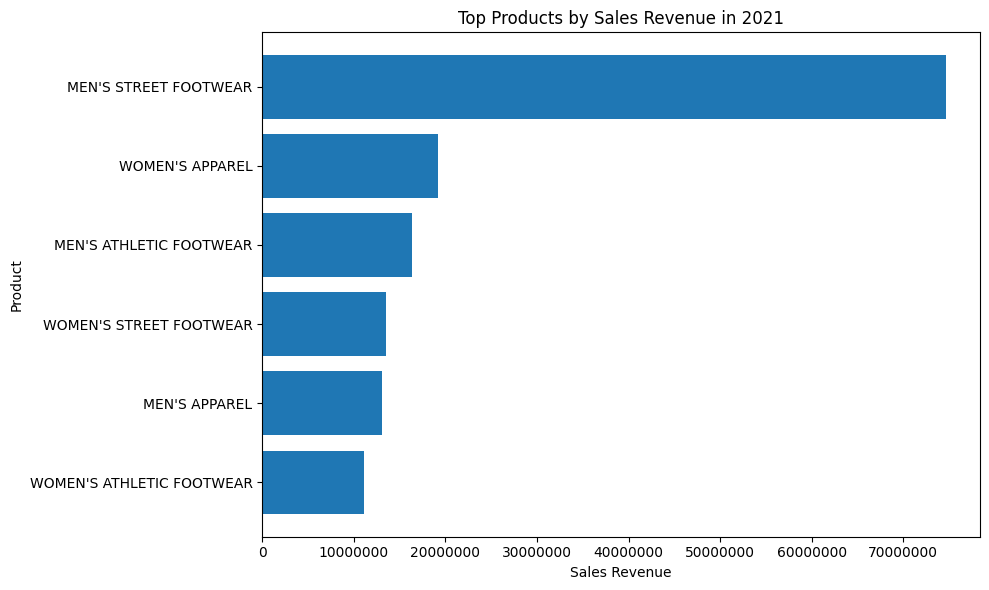

In [25]:
top_products_2021 = product_sales_2021.head(10).sort_values(
    "SALES_REVENUE"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_products_2021["PRODUCT_NAME"],
    top_products_2021["SALES_REVENUE"]
)

plt.title("Top Products by Sales Revenue in 2021")
plt.xlabel("Sales Revenue")
plt.ylabel("Product")
plt.ticklabel_format(style="plain", axis="x")
plt.tight_layout()
plt.show()

#Question 2: State with highest women’s product sales

In [26]:
womens_sales_2021 = sales_2021[
    sales_2021["PRODUCT_GENDER"] == "Women's"
].copy()


womens_state_sales_2021 = (
    womens_sales_2021
    .groupby("STATE", as_index=False)
    .agg(
        SALES_REVENUE=("SALES_REVENUE", "sum"),
        UNITS_SOLD=("UNITS_SOLD", "sum"),
        ORDERS=("ORDER_ID", "nunique")
    )
    .sort_values("SALES_REVENUE", ascending=False)
)


if womens_state_sales_2021.empty:
    print(
        "No products were identified as women's products in 2021. "
        "Review the product names and classification rules."
    )

else:
    question_2 = womens_state_sales_2021.iloc[0]

    print("QUESTION 2")
    print("-" * 60)
    print(
        f"The state with the highest women's product sales "
        f"in 2021 was {question_2['STATE']}."
    )
    print(
        f"Women's product sales: "
        f"${question_2['SALES_REVENUE']:,.2f}"
    )

display(womens_state_sales_2021)

QUESTION 2
------------------------------------------------------------
The state with the highest women's product sales in 2021 was Maine.
Women's product sales: $2,176,301.00


,STATE,SALES_REVENUE,UNITS_SOLD,ORDERS
18,Maine,"2,176,301.00","37,697.00",57
7,Delaware,"2,023,575.00","41,665.00",74
28,New Hampshire,"1,916,400.00","38,690.00",107
2,Arizona,"1,798,900.00","30,465.00",109
24,Missouri,"1,771,992.00","26,790.00",71
12,Illinois,"1,743,277.00","35,517.00",71
45,Virginia,"1,719,886.00","37,076.00",109
26,Nebraska,"1,712,680.00","33,038.00",71
6,Connecticut,"1,600,156.00","30,469.00",107
31,New York,"1,505,256.00","38,841.00",161


#Chart for Question 2

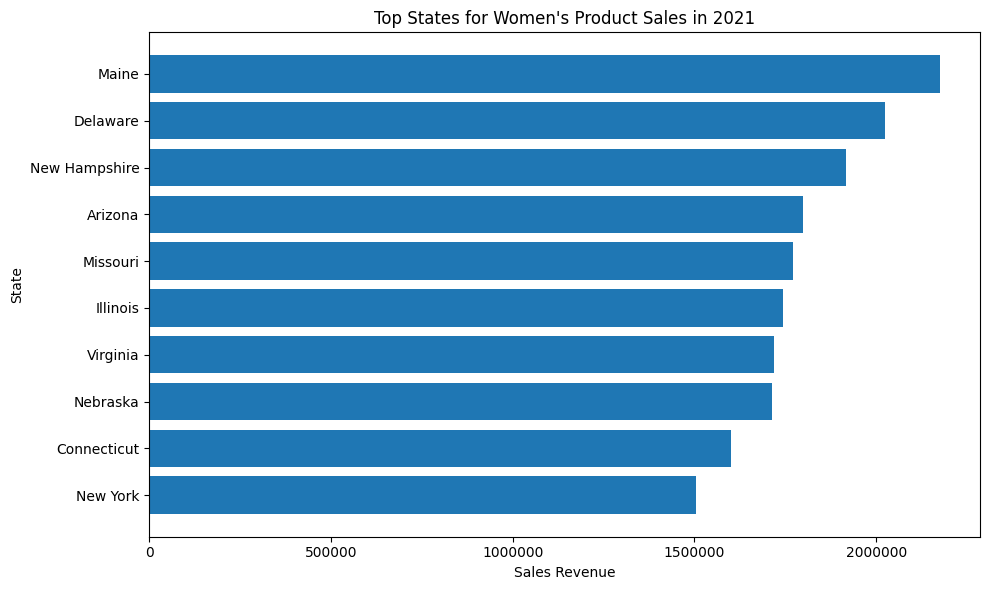

In [27]:
top_womens_states = womens_state_sales_2021.head(10).sort_values(
    "SALES_REVENUE"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_womens_states["STATE"],
    top_womens_states["SALES_REVENUE"]
)

plt.title("Top States for Women's Product Sales in 2021")
plt.xlabel("Sales Revenue")
plt.ylabel("State")
plt.ticklabel_format(style="plain", axis="x")
plt.tight_layout()
plt.show()

#Question 3: State with highest men’s product sales

In [28]:
mens_sales_2021 = sales_2021[
    sales_2021["PRODUCT_GENDER"] == "Men's"
].copy()


mens_state_sales_2021 = (
    mens_sales_2021
    .groupby("STATE", as_index=False)
    .agg(
        SALES_REVENUE=("SALES_REVENUE", "sum"),
        UNITS_SOLD=("UNITS_SOLD", "sum"),
        ORDERS=("ORDER_ID", "nunique")
    )
    .sort_values("SALES_REVENUE", ascending=False)
)


if mens_state_sales_2021.empty:
    print(
        "No products were identified as men's products in 2021. "
        "Review the product names and classification rules."
    )

else:
    question_3 = mens_state_sales_2021.iloc[0]

    print("QUESTION 3")
    print("-" * 60)
    print(
        f"The state with the highest men's product sales "
        f"in 2021 was {question_3['STATE']}."
    )
    print(
        f"Men's product sales: "
        f"${question_3['SALES_REVENUE']:,.2f}"
    )

display(mens_state_sales_2021)

QUESTION 3
------------------------------------------------------------
The state with the highest men's product sales in 2021 was New Hampshire.
Men's product sales: $54,208,080.00


,STATE,SALES_REVENUE,UNITS_SOLD,ORDERS
28,New Hampshire,"54,208,080.00","46,305.00",109
7,Delaware,"2,334,300.00","45,305.00",70
2,Arizona,"2,261,025.00","37,850.00",107
18,Maine,"2,217,190.00","40,376.00",58
12,Illinois,"2,093,438.00","40,426.00",72
24,Missouri,"1,951,530.00","31,098.00",73
6,Connecticut,"1,926,568.00","35,077.00",109
31,New York,"1,847,069.00","45,586.00",160
26,Nebraska,"1,718,726.00","36,501.00",73
30,New Mexico,"1,708,196.00","32,189.00",107


#Chart for Question 3

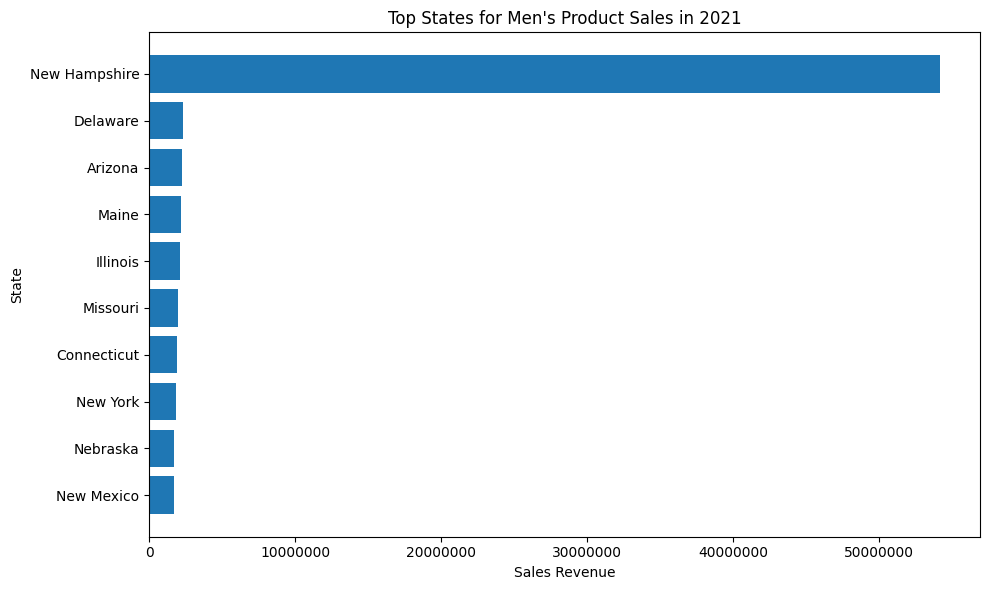

In [29]:
top_mens_states = mens_state_sales_2021.head(10).sort_values(
    "SALES_REVENUE"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_mens_states["STATE"],
    top_mens_states["SALES_REVENUE"]
)

plt.title("Top States for Men's Product Sales in 2021")
plt.xlabel("Sales Revenue")
plt.ylabel("State")
plt.ticklabel_format(style="plain", axis="x")
plt.tight_layout()
plt.show()

#Question 4: Retailer with most units in 2021 and 2020

In [30]:
retailer_units_by_year = (
    rush_df[
        rush_df["YEAR"].isin([2020, 2021])
    ]
    .groupby(["YEAR", "RETAILER"], as_index=False)
    .agg(
        UNITS_SOLD=("UNITS_SOLD", "sum"),
        SALES_REVENUE=("SALES_REVENUE", "sum"),
        ORDERS=("ORDER_ID", "nunique")
    )
    .sort_values(
        ["YEAR", "UNITS_SOLD"],
        ascending=[True, False]
    )
)


top_retailer_each_year = (
    retailer_units_by_year
    .groupby("YEAR", as_index=False)
    .first()
)


print("QUESTION 4")
print("-" * 60)

for year in [2021, 2020]:

    result = top_retailer_each_year[
        top_retailer_each_year["YEAR"] == year
    ]

    if result.empty:
        print(f"No sales data was found for {year}.")

    else:
        row = result.iloc[0]

        print(
            f"{year}: {row['RETAILER']} sold the most units, "
            f"with {row['UNITS_SOLD']:,.0f} units."
        )

display(top_retailer_each_year)

QUESTION 4
------------------------------------------------------------
2021: Foot Locker sold the most units, with 1,097,410 units.
2020: Amazon sold the most units, with 316,880 units.


,YEAR,RETAILER,UNITS_SOLD,SALES_REVENUE,ORDERS
0,2020,Amazon,"316,880.00","17,475,150.00",528
1,2021,Foot Locker,"1,097,410.00","105,619,905.00",2637


#Compare top retailers by year

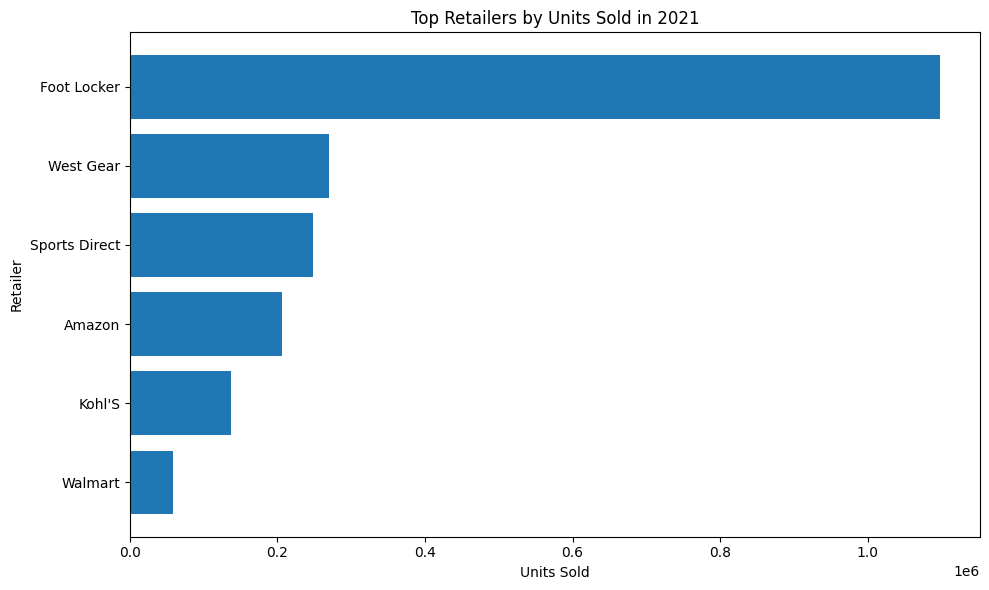

In [31]:
top_10_retailers_2021 = (
    retailer_units_by_year[
        retailer_units_by_year["YEAR"] == 2021
    ]
    .head(10)
    .sort_values("UNITS_SOLD")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_retailers_2021["RETAILER"],
    top_10_retailers_2021["UNITS_SOLD"]
)

plt.title("Top Retailers by Units Sold in 2021")
plt.xlabel("Units Sold")
plt.ylabel("Retailer")
plt.tight_layout()
plt.show()

# Additional business insights

Annual performance

In [32]:
annual_performance = (
    rush_df
    .groupby("YEAR", as_index=False)
    .agg(
        SALES_REVENUE=("SALES_REVENUE", "sum"),
        UNITS_SOLD=("UNITS_SOLD", "sum"),
        OPERATING_PROFIT=("OPERATING_PROFIT", "sum"),
        ORDERS=("ORDER_ID", "nunique")
    )
    .sort_values("YEAR")
)


annual_performance["SALES_GROWTH_PERCENT"] = (
    annual_performance["SALES_REVENUE"]
    .pct_change() * 100
)


annual_performance["AVERAGE_REVENUE_PER_ORDER"] = (
    annual_performance["SALES_REVENUE"] /
    annual_performance["ORDERS"]
)


display(annual_performance)

,YEAR,SALES_REVENUE,UNITS_SOLD,OPERATING_PROFIT,ORDERS,SALES_GROWTH_PERCENT,AVERAGE_REVENUE_PER_ORDER
0,2020,"24,174,325.00","461,299.00","8,988,730.08",1300,NaN,"18,595.63"
1,2021,"147,888,456.00","2,016,131.00","58,992,330.58",8344,511.76,"17,723.93"


Monthly seasonality

In [33]:
monthly_sales = (
    rush_df
    .groupby(
        ["YEAR", "MONTH_NUMBER", "MONTH"],
        as_index=False
    )
    .agg(
        SALES_REVENUE=("SALES_REVENUE", "sum"),
        UNITS_SOLD=("UNITS_SOLD", "sum"),
        OPERATING_PROFIT=("OPERATING_PROFIT", "sum")
    )
    .sort_values(["YEAR", "MONTH_NUMBER"])
)

display(monthly_sales)

,YEAR,MONTH_NUMBER,MONTH,SALES_REVENUE,UNITS_SOLD,OPERATING_PROFIT
0,2020,1,January,"2,312,746.00","48,333.00","883,774.16"
1,2020,2,February,"2,140,813.00","37,846.00","796,848.19"
2,2020,3,March,"2,474,202.00","46,972.00","879,268.76"
3,2020,4,April,"3,130,081.00","53,659.00","1,248,667.09"
4,2020,5,May,"2,164,764.00","35,705.00","800,635.70"
5,2020,6,June,"1,084,194.00","16,269.00","307,046.16"
6,2020,7,July,"2,182,388.00","38,219.00","681,477.61"
7,2020,8,August,"2,641,630.00","62,307.00","1,042,648.29"
8,2020,9,September,"2,367,686.00","46,125.00","975,908.69"
9,2020,10,October,"1,428,569.00","30,167.00","582,342.96"


Highest and lowest sales months

In [34]:
monthly_totals = (
    rush_df
    .groupby(["MONTH_NUMBER", "MONTH"], as_index=False)
    .agg(
        SALES_REVENUE=("SALES_REVENUE", "sum"),
        UNITS_SOLD=("UNITS_SOLD", "sum")
    )
    .sort_values("MONTH_NUMBER")
)


highest_month = monthly_totals.loc[
    monthly_totals["SALES_REVENUE"].idxmax()
]

lowest_month = monthly_totals.loc[
    monthly_totals["SALES_REVENUE"].idxmin()
]


print(
    f"Highest overall sales month: {highest_month['MONTH']} "
    f"with ${highest_month['SALES_REVENUE']:,.2f}"
)

print(
    f"Lowest overall sales month: {lowest_month['MONTH']} "
    f"with ${lowest_month['SALES_REVENUE']:,.2f}"
)

display(monthly_totals)

Highest overall sales month: May with $62,707,550.00
Lowest overall sales month: March with $7,694,984.00


,MONTH_NUMBER,MONTH,SALES_REVENUE,UNITS_SOLD
0,1,January,"9,744,767.00","227,632.00"
1,2,February,"8,263,853.00","193,959.00"
2,3,March,"7,694,984.00","190,960.00"
3,4,April,"9,628,420.00","215,376.00"
4,5,May,"62,707,550.00","214,455.00"
5,6,June,"9,803,147.00","181,014.00"
6,7,July,"12,550,419.00","218,700.00"
7,8,August,"12,293,226.00","257,721.00"
8,9,September,"10,405,584.00","228,550.00"
9,10,October,"8,538,758.00","183,001.00"


Regional sales performance

In [35]:
regional_performance = (
    rush_df
    .groupby("REGION", as_index=False)
    .agg(
        SALES_REVENUE=("SALES_REVENUE", "sum"),
        UNITS_SOLD=("UNITS_SOLD", "sum"),
        OPERATING_PROFIT=("OPERATING_PROFIT", "sum"),
        ORDERS=("ORDER_ID", "nunique")
    )
    .sort_values("SALES_REVENUE", ascending=False)
)


regional_performance["SALES_SHARE_PERCENT"] = (
    regional_performance["SALES_REVENUE"] /
    regional_performance["SALES_REVENUE"].sum() *
    100
)


display(regional_performance)

,REGION,SALES_REVENUE,UNITS_SOLD,OPERATING_PROFIT,ORDERS,SALES_SHARE_PERCENT
1,Northeast,"90,747,368.00","783,620.00","35,513,083.83",2374,52.75
0,Midwest,"31,433,570.00","635,335.00","12,108,507.66",1870,18.27
4,West,"24,820,550.00","516,791.00","9,503,500.12",2448,14.43
3,Southeast,"14,726,189.00","312,074.00","6,193,714.23",1224,8.56
2,South,"10,317,224.00","229,312.00","4,654,745.22",1727,6.00


Product profitability

In [36]:
product_profitability = (
    rush_df
    .groupby("PRODUCT_NAME", as_index=False)
    .agg(
        SALES_REVENUE=("SALES_REVENUE", "sum"),
        UNITS_SOLD=("UNITS_SOLD", "sum"),
        OPERATING_PROFIT=("OPERATING_PROFIT", "sum"),
        AVERAGE_MARGIN=("OPERATING_MARGIN", "mean")
    )
    .sort_values("OPERATING_PROFIT", ascending=False)
)


product_profitability["PROFIT_PER_UNIT"] = (
    product_profitability["OPERATING_PROFIT"] /
    product_profitability["UNITS_SOLD"].replace(0, np.nan)
)


display(product_profitability)

,PRODUCT_NAME,SALES_REVENUE,UNITS_SOLD,OPERATING_PROFIT,AVERAGE_MARGIN,PROFIT_PER_UNIT
2,MEN'S STREET FOOTWEAR,"79,576,900.00","591,889.00","32,385,138.58",0.45,54.71
3,WOMEN'S APPAREL,"23,870,985.00","433,827.00","9,685,220.56",0.44,22.33
1,MEN'S ATHLETIC FOOTWEAR,"20,577,180.00","435,526.00","7,437,456.94",0.40,17.08
5,WOMEN'S STREET FOOTWEAR,"17,201,563.00","392,269.00","6,494,016.81",0.41,16.56
0,MEN'S APPAREL,"16,520,632.00","306,683.00","6,381,405.33",0.41,20.81
4,WOMEN'S ATHLETIC FOOTWEAR,"14,315,521.00","317,236.00","5,597,822.44",0.42,17.65
